# <center> Problem Statement </center>

An agriculture company currently relies on manual methods to classify different types of dry beans. This process is time-consuming, error-prone, and inefficient when dealing with large-scale production.

The objective of this project is to build a machine learning model that can automatically classify dry beans into their respective categories based on their physical and geometrical characteristics.

By leveraging supervised learning techniques, this solution aims to:

- Automate the bean classification process
- Reduce human effort and operational costs
- Improve classification accuracy and consistency
- Enable scalable and real-time quality control in agricultural processing

This project demonstrates the application of machine learning in the Agri-tech domain, specifically in quality inspection and product classification.

# <center>Data Overview</center>

The dataset used in this project contains measurements of dry beans obtained using computer vision techniques. Each row represents a single bean sample, and each column represents a specific physical or shape-related feature.

The dataset includes:

- Multiple numerical features describing size, shape, and geometry
- A target variable (`Class`) indicating the type of bean

### Key Characteristics:

- Data is collected using camera-based systems
- Features are derived using image processing algorithms
- Suitable for supervised multi-class classification

### Target Variable:

- `Class`: Represents the type of dry bean
- Categories include:
  - Seker
  - Barbunya
  - Bombay
  - Cali
  - Dermosan
  - Horoz
  - Sira

### Objective:

Use the given features to train a machine learning model that can accurately predict the bean type.

# <center>Data Dictionary</center>

Below is the description of each feature present in the dataset:

| Feature Name        | Description |
|--------------------|-------------|
| Area (A)           | Total number of pixels within the boundary of the bean |
| Perimeter (P)      | Length of the boundary of the bean |
| MajorAxisLength (L)| Longest diameter of the bean |
| MinorAxisLength (l)| Shortest diameter perpendicular to the major axis |
| AspectRatio (K)    | Ratio of Major Axis Length to Minor Axis Length |
| Eccentricity (Ec)  | Measure of how much the bean shape deviates from a circle |
| ConvexArea (C)     | Area of the smallest convex shape that encloses the bean |
| EquivDiameter (Ed) | Diameter of a circle having the same area as the bean |
| Extent (Ex)        | Ratio of bean area to bounding box area |
| Solidity (S)       | Ratio of bean area to convex area |
| Roundness (R)      | Measure of circularity calculated as (4πA) / (P²) |
| Compactness (CO)   | Ratio of equivalent diameter to major axis length |
| ShapeFactor1 (SF1) | Derived shape descriptor based on geometry |
| ShapeFactor2 (SF2) | Derived shape descriptor based on geometry |
| ShapeFactor3 (SF3) | Derived shape descriptor based on geometry |
| ShapeFactor4 (SF4) | Derived shape descriptor based on geometry |
| Class              | Target variable representing bean type |


In [2]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
import re

# <center>Data Loading & Understanding</center>

In [3]:
# Loading the dataset
df = pd.read_csv("Beans_Multiclass_Classification.csv")

In [4]:
# top 5 rows
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
# Checking the shape
df.shape

(13611, 17)

In [6]:
# Checking the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [7]:
# Checking the statistical summary of numerical features
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [8]:
# Checking the statistical summary of categorical features
df.describe(include='object')

,Class
count,13611
unique,7
top,DERMASON
freq,3546


In [9]:
# Checking the columns name
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

# <center>Data Cleaning</center>

In [10]:
# Cleaning column names
def clean_columns(col):
    col = col.strip()
    
    # Add space before capital letters
    col = re.sub(r'(?<!^)(?=[A-Z])', ' ', col)
    
    # Add space before numbers
    col = re.sub(r'(\d+)', r' \1', col)
    
    # Convert to lowercase
    col = col.lower()
    
    # Replace spaces with underscore
    col = col.replace(" ", "_")
    
    return col

df.columns = [clean_columns(col) for col in df.columns]

# Fix specific mistakes
df.rename(columns={
    "aspect_ration": "aspect_ratio"
}, inplace=True)

df.columns

Index(['area', 'perimeter', 'major_axis_length', 'minor_axis_length',
       'aspect_ratio', 'eccentricity', 'convex_area', 'equiv_diameter',
       'extent', 'solidity', 'roundness', 'compactness', 'shape_factor_1',
       'shape_factor_2', 'shape_factor_3', 'shape_factor_4', 'class'],
      dtype='object')

In [11]:
# Checking for duplicates
df.duplicated().sum()

np.int64(68)

In [12]:
# Removing the duplicated rows
df.drop_duplicates(inplace=True)

In [13]:
# Now Checking the shapes of dataset
df.shape

(13543, 17)

In [14]:
# Checking for nulls
df.isnull().sum()

area                 0
perimeter            0
major_axis_length    0
minor_axis_length    0
aspect_ratio         0
eccentricity         0
convex_area          0
equiv_diameter       0
extent               0
solidity             0
roundness            0
compactness          0
shape_factor_1       0
shape_factor_2       0
shape_factor_3       0
shape_factor_4       0
class                0
dtype: int64

In [15]:
# Creating a list of num_cols and cat_cols
num_cols = df.select_dtypes(include='number').columns.to_list()
cat_cols = df.select_dtypes(exclude='number').columns.to_list()
print(f"Total Numerical columns we have {len(num_cols)} i.e. {num_cols}")
print(f"Total Categorical columns we have {len(cat_cols)} i.e. {cat_cols}")

Total Numerical columns we have 16 i.e. ['area', 'perimeter', 'major_axis_length', 'minor_axis_length', 'aspect_ratio', 'eccentricity', 'convex_area', 'equiv_diameter', 'extent', 'solidity', 'roundness', 'compactness', 'shape_factor_1', 'shape_factor_2', 'shape_factor_3', 'shape_factor_4']
Total Categorical columns we have 1 i.e. ['class']


# <center>Univariate Analysis</center>

In [16]:
# Checking the unique categories in categorical columns
for col in cat_cols:
    print('--------------------------------------------')
    print(f'Column: {col}')
    print(f'Number of unique values: {df[col].nunique()}')
    print(df[col].value_counts().head(10))
print('--------------------------------------------')

--------------------------------------------
Column: class
Number of unique values: 7
class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
--------------------------------------------


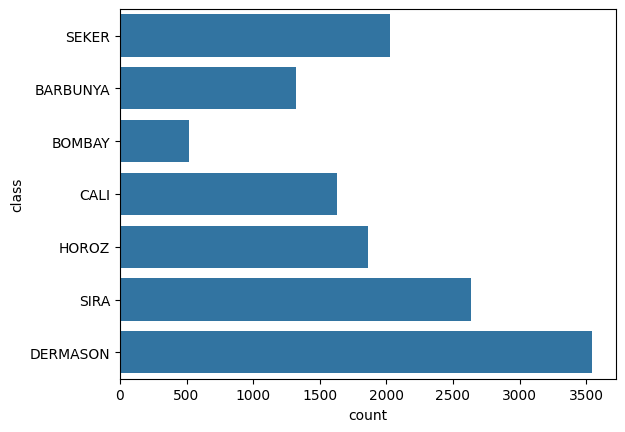

In [17]:
# Checking the countplot of categorical variables
for col in cat_cols:
    sns.countplot(df[col])
    plt.show()

In [18]:
# Checking the category wise percentage in target variable
counts = df['class'].value_counts()
percentage = df['class'].value_counts(normalize=True) * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage': percentage
})

print(result)

          Count  Percentage
class                      
DERMASON   3546   26.183268
SIRA       2636   19.463930
SEKER      2027   14.967142
HOROZ      1860   13.734032
CALI       1630   12.035738
BARBUNYA   1322    9.761500
BOMBAY      522    3.854390


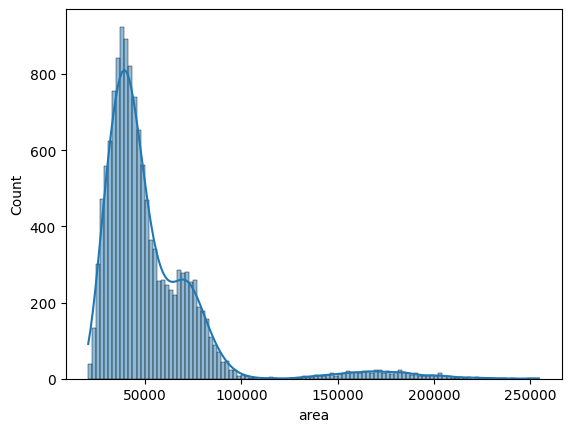

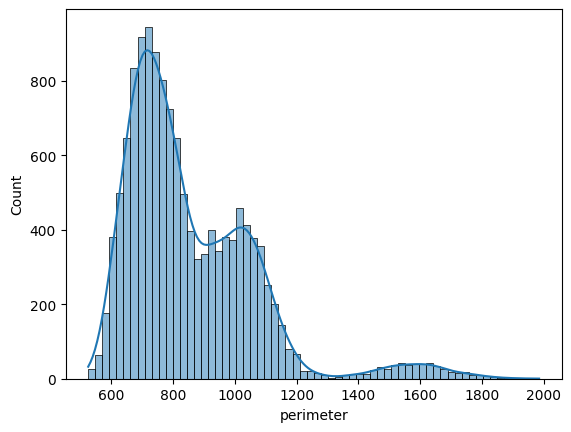

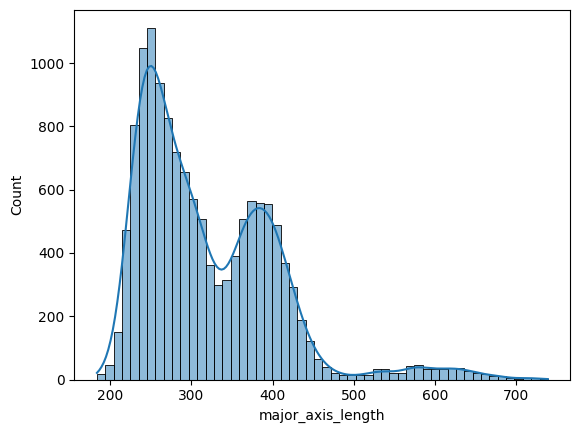

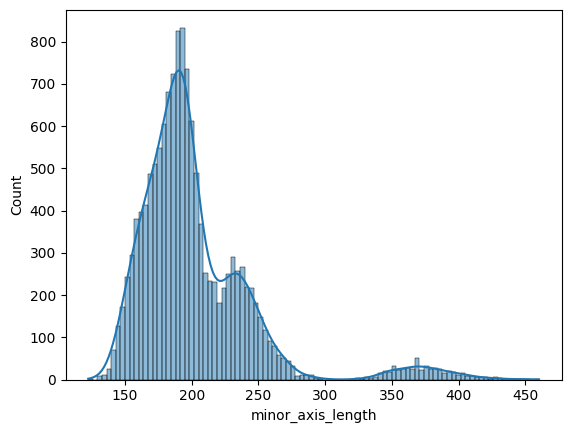

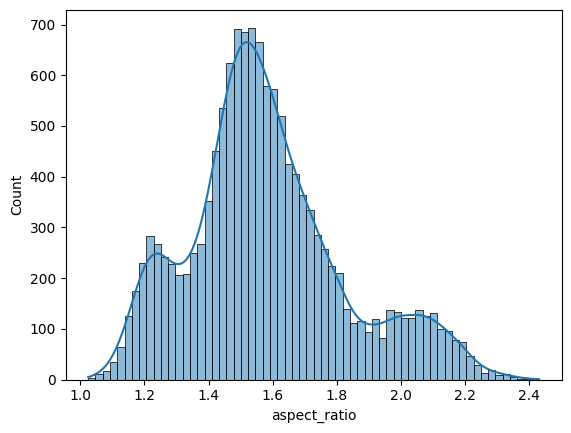

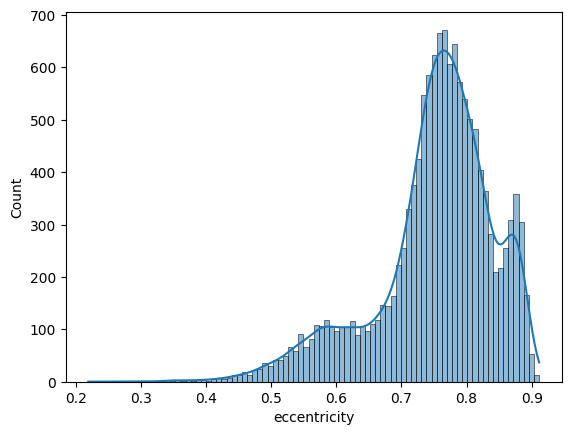

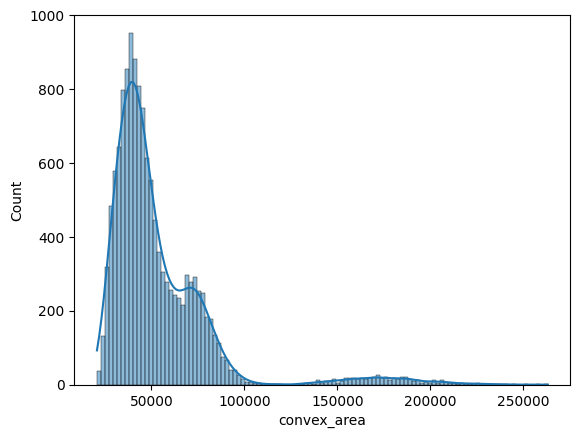

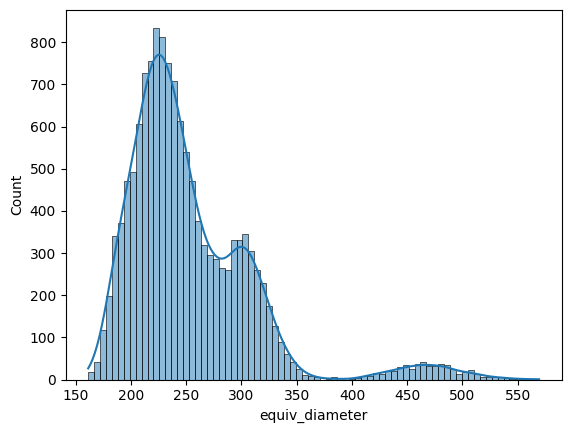

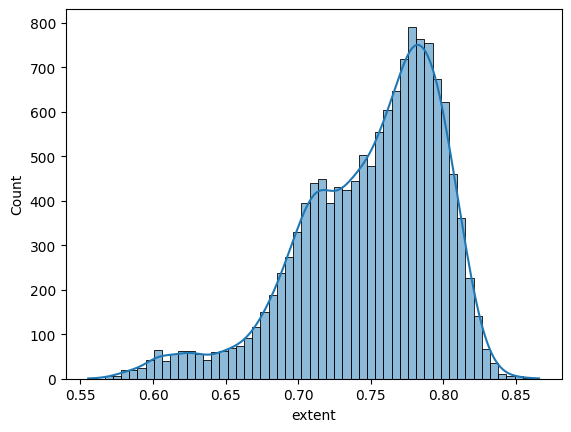

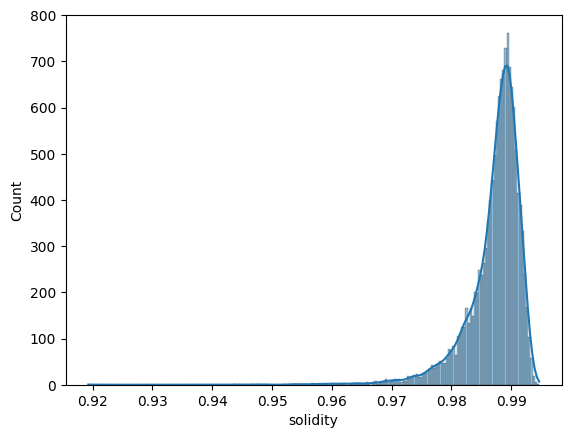

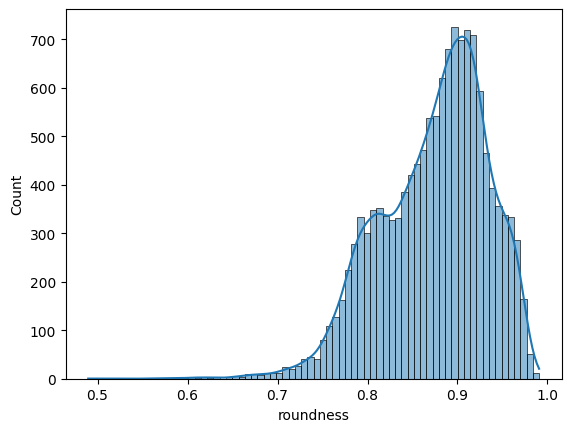

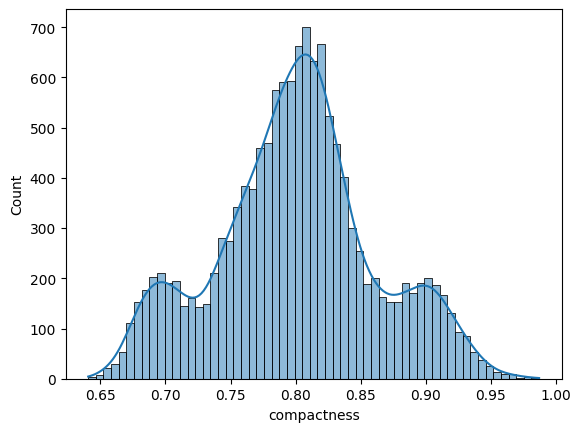

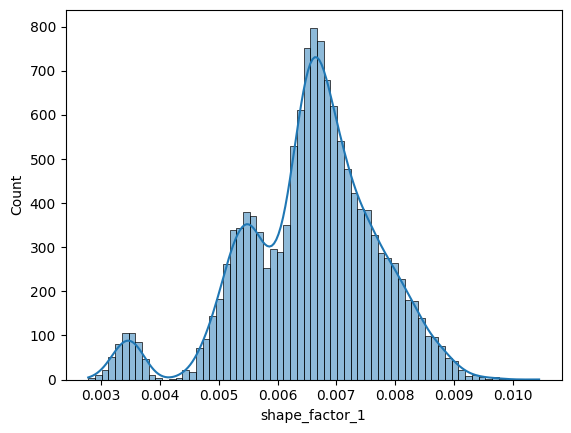

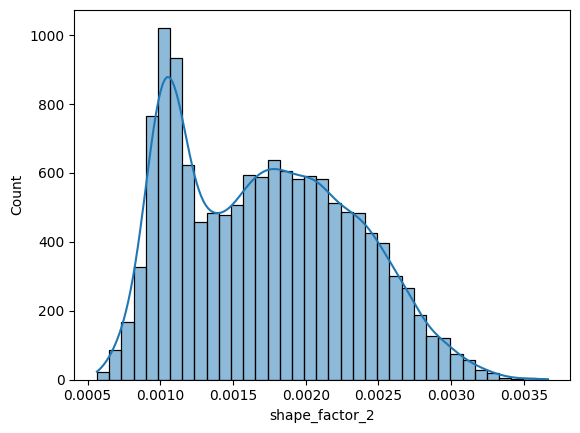

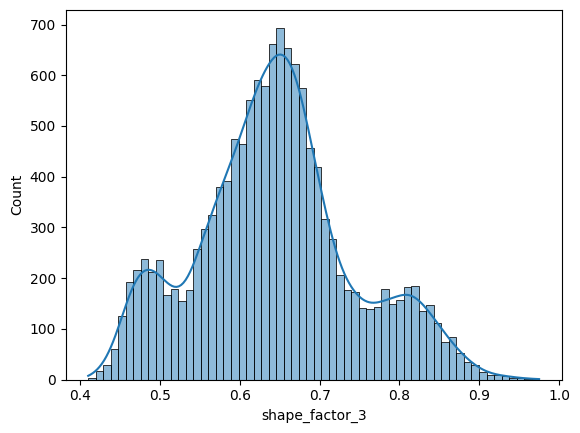

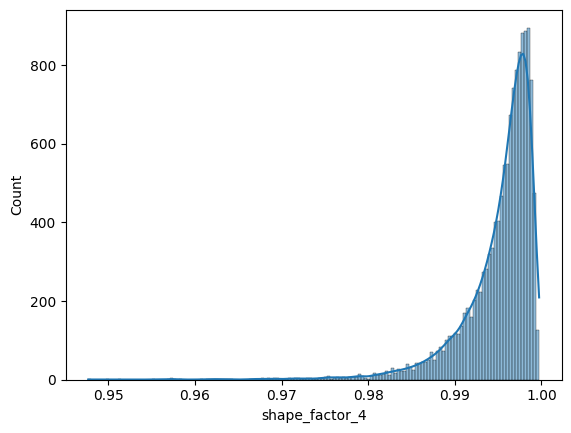

In [19]:
# Checking the distribution of numerical variables
for col in num_cols:
    sns.histplot(df[col],kde=True)
    plt.show()

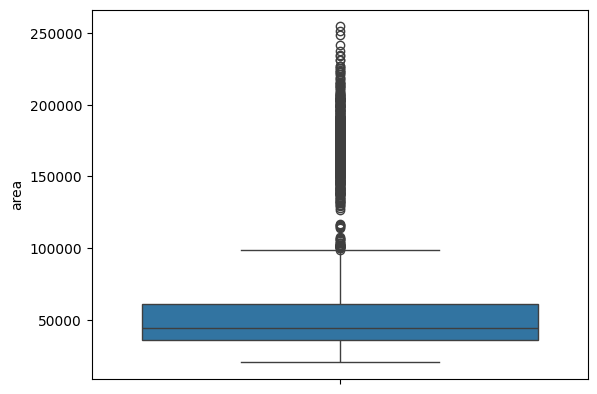

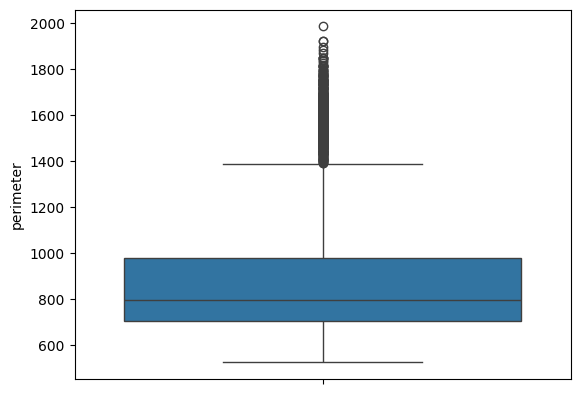

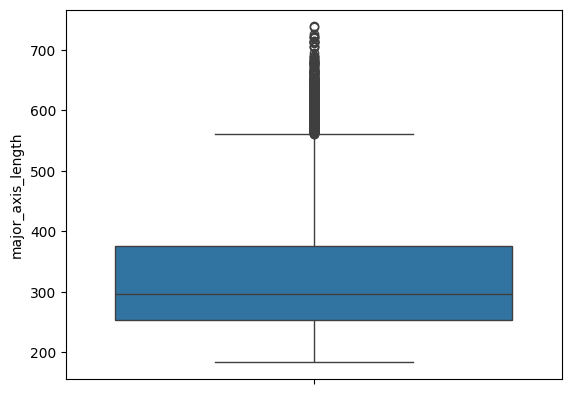

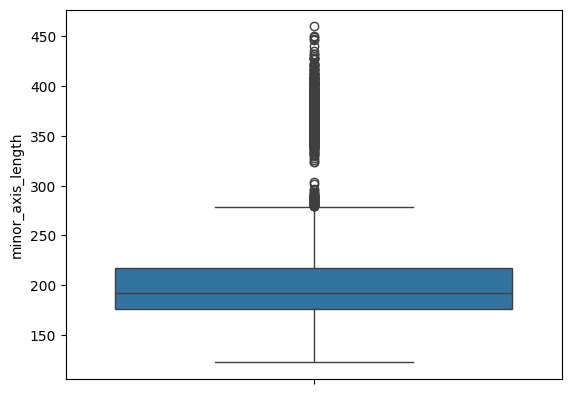

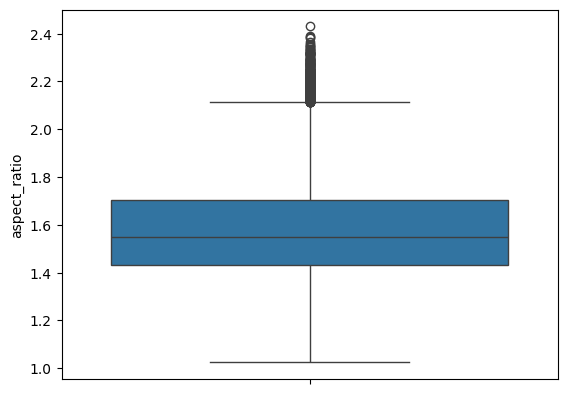

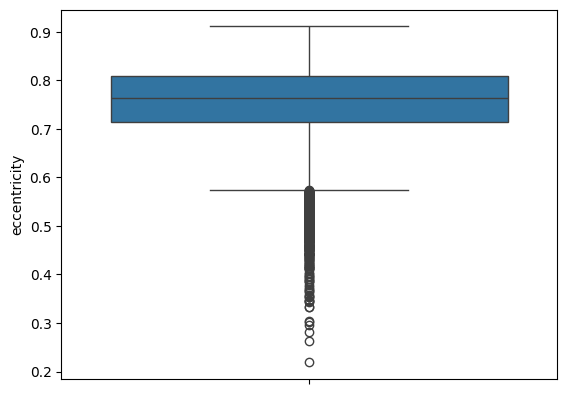

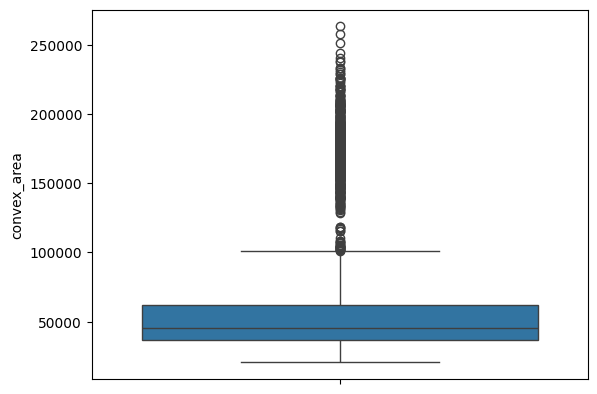

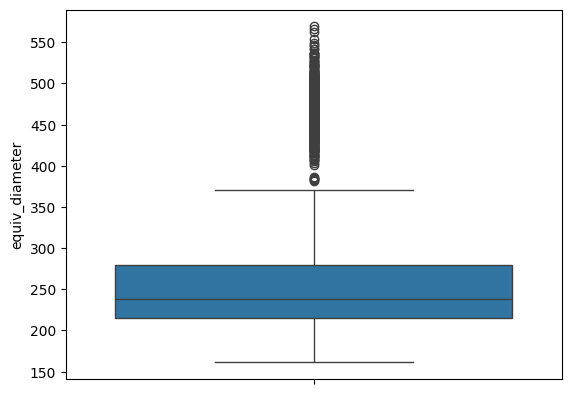

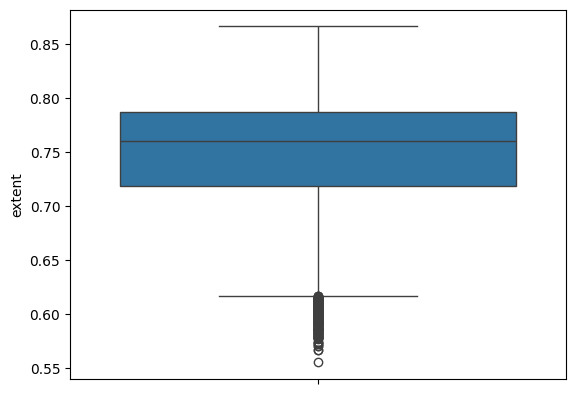

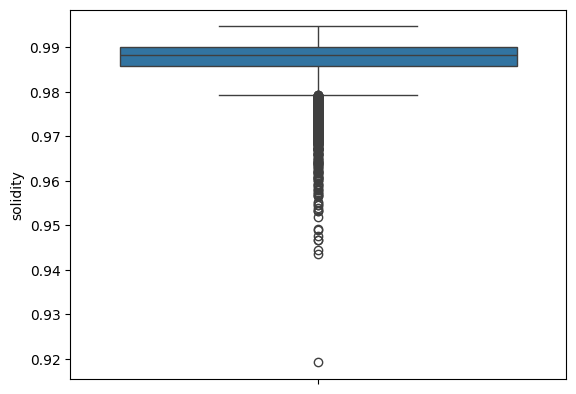

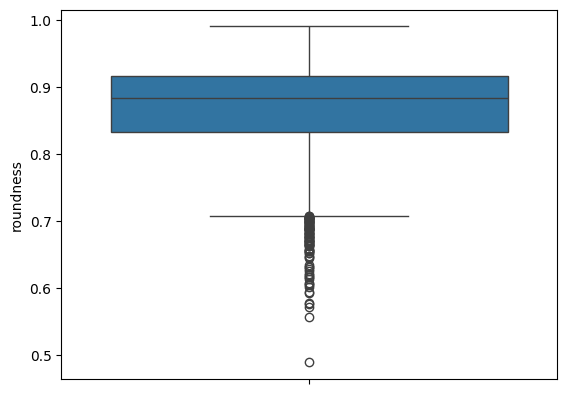

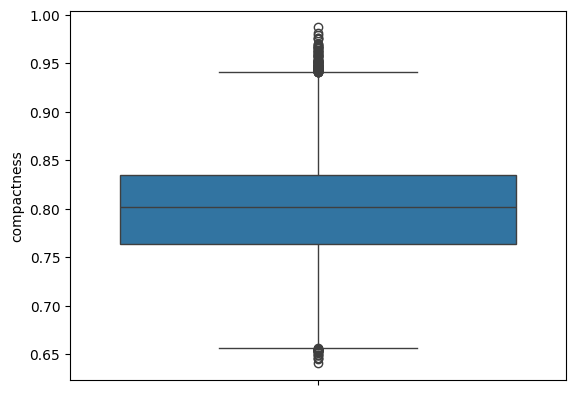

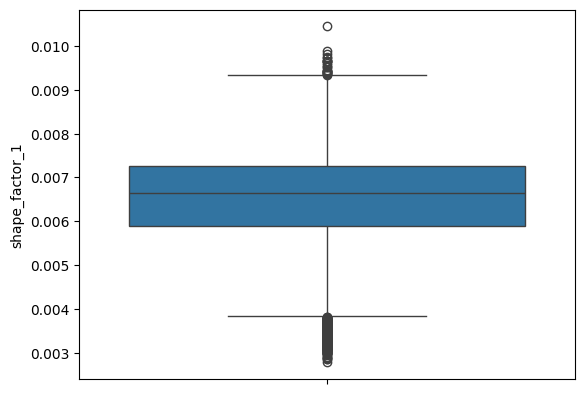

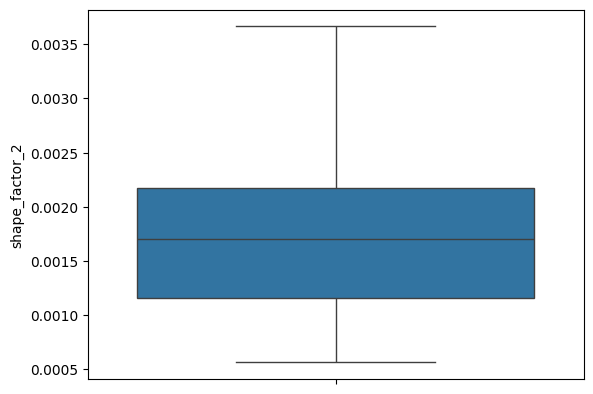

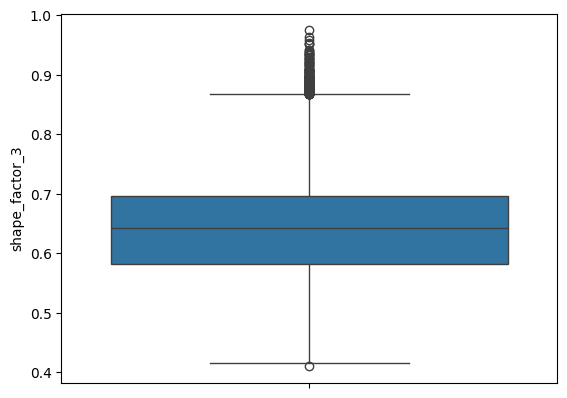

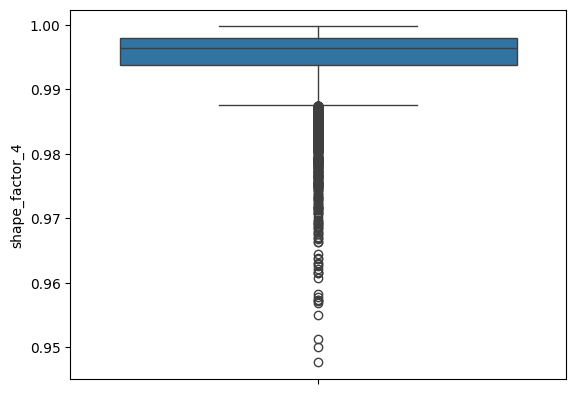

In [20]:
# Checking the outliers using Box plot
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()

In [21]:
# Checking the skewness of numerical cols
df[num_cols].skew().sort_values(ascending=False)

area                 2.947136
convex_area          2.936102
minor_axis_length    2.232013
equiv_diameter       1.947303
perimeter            1.628018
major_axis_length    1.365813
aspect_ratio         0.589045
shape_factor_2       0.294332
shape_factor_3       0.242767
compactness          0.036309
shape_factor_1      -0.530427
roundness           -0.648725
extent              -0.895655
eccentricity        -1.064932
solidity            -2.546877
shape_factor_4      -2.760125
dtype: float64

# <center>Bivariate Analysis</center>

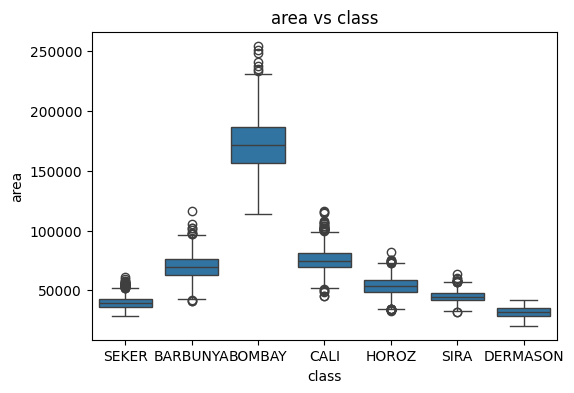

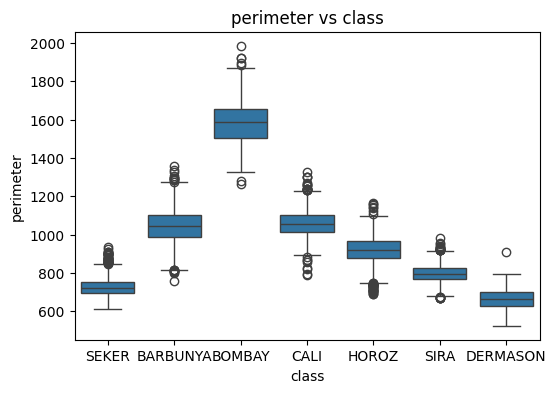

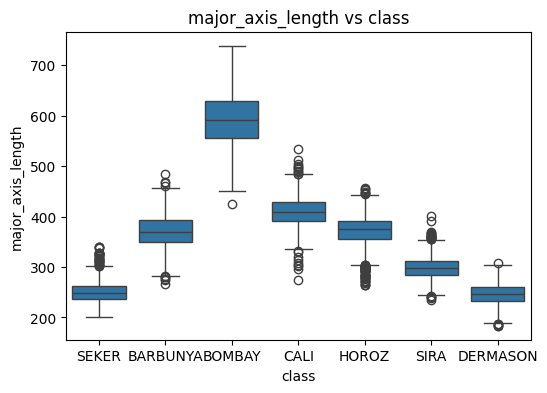

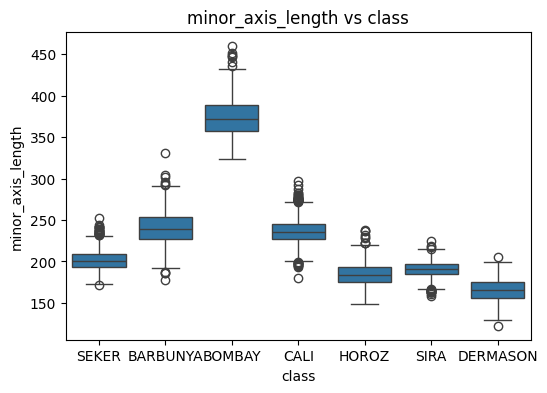

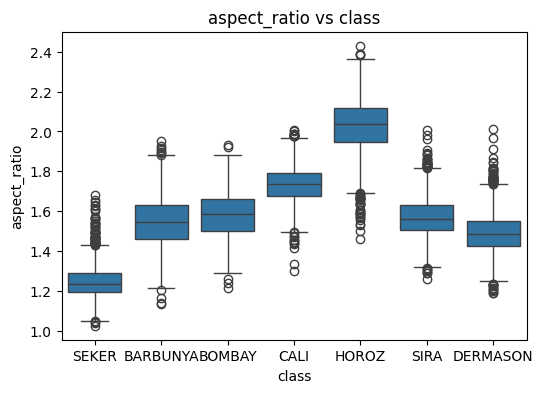

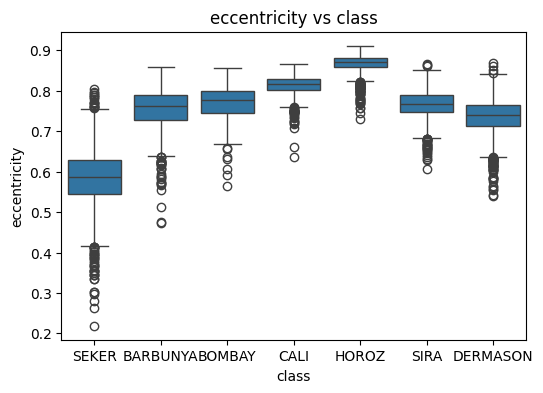

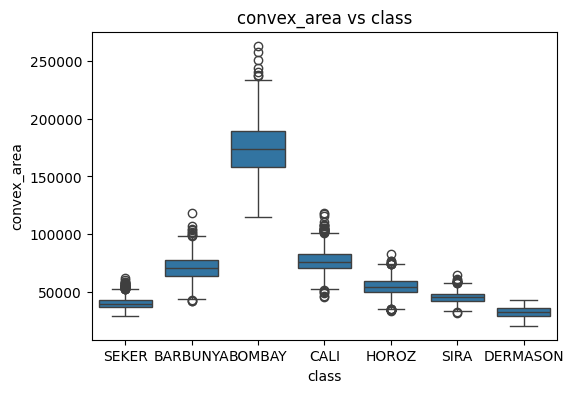

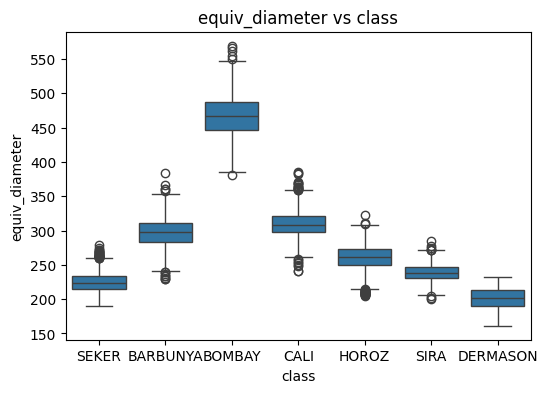

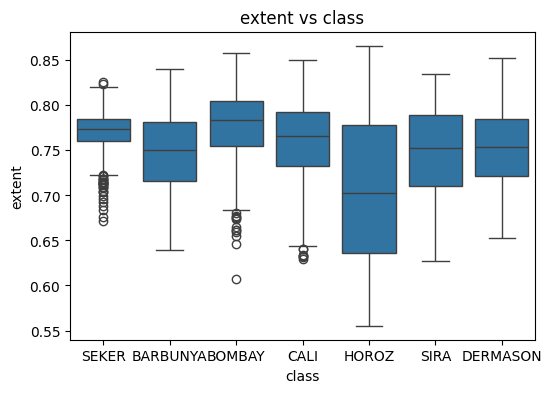

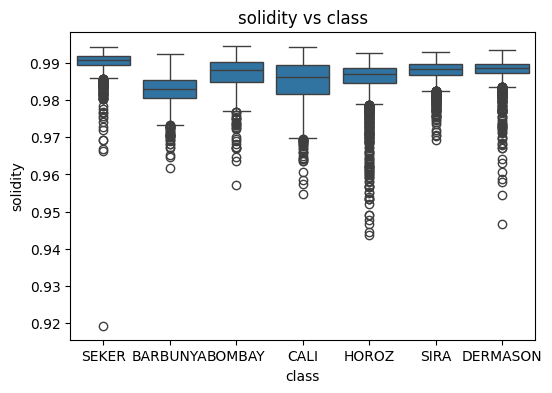

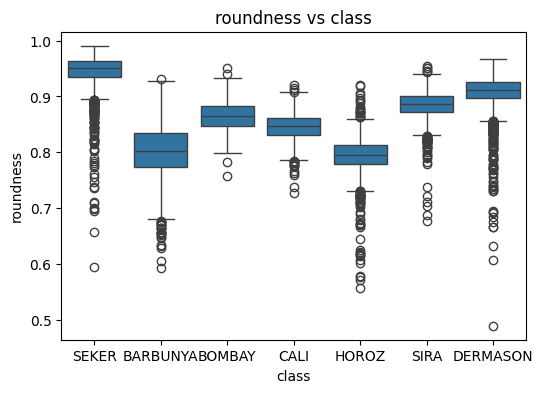

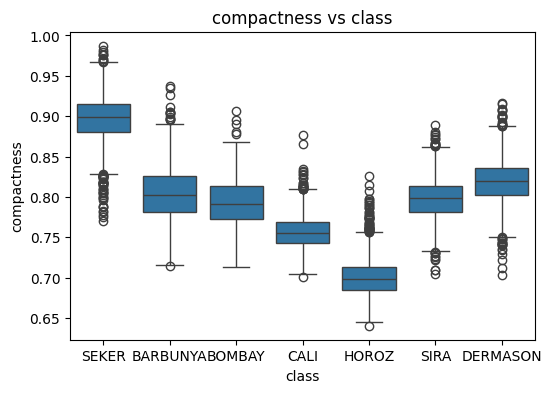

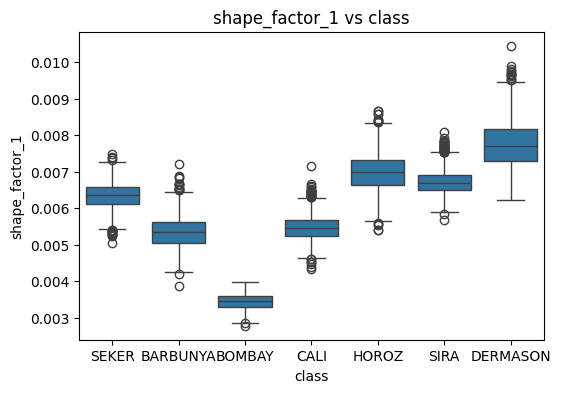

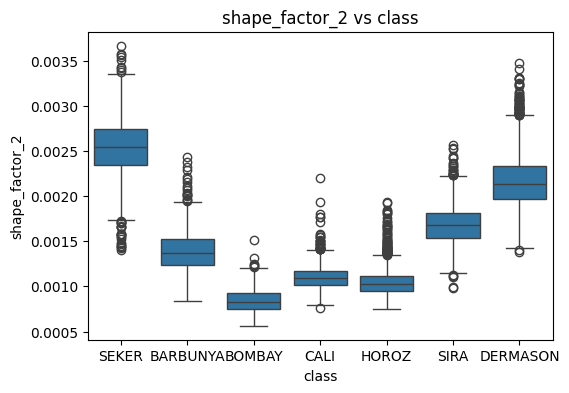

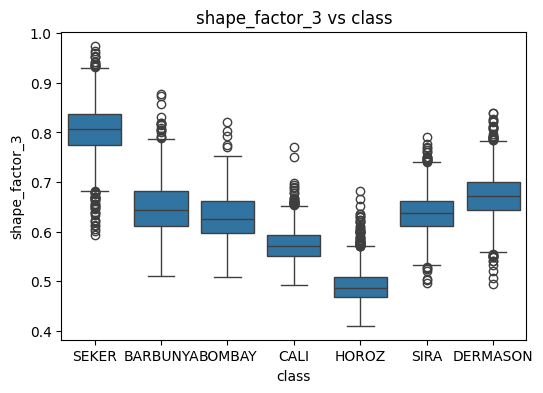

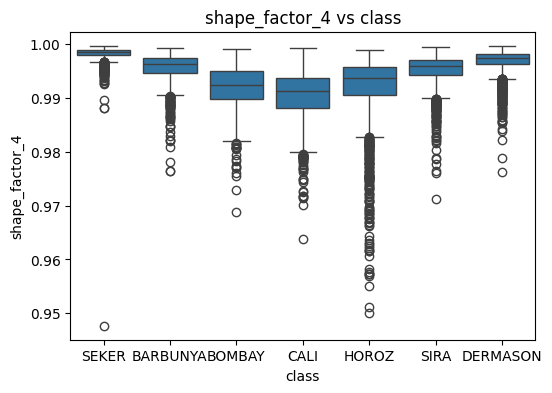

In [22]:
# Numerical Features Vs Categorical Target
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='class', y=col, data=df)
    plt.title(f'{col} vs class')
    plt.show()

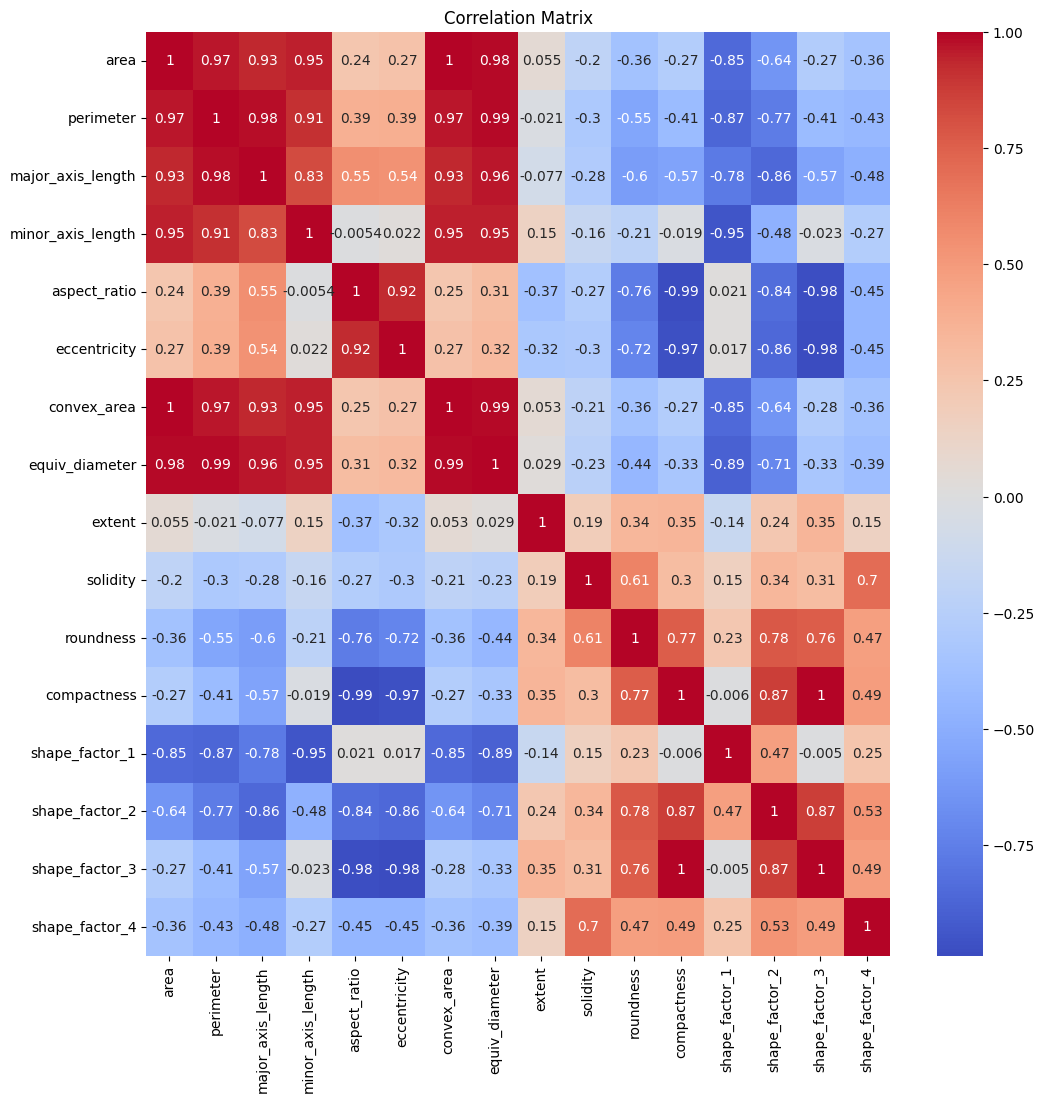

In [23]:
# Correlation matrix

plt.figure(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# <center> TrainTest Split</center>

In [24]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# <center>Baseline Model</center>

In [68]:
# Creating Baseline Model for logisticRegression, SVM, KNN, Naive Bayes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Selecting cat_cols and num_cols for preprocessing
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

# Using ColumnTransformer Doing the preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols)
], remainder='passthrough')

# Creating a dictionary of models
models = {
    "LogisticRegression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(),
    "NaiveBayes": GaussianNB()
}

# Creating a empty list of baseline_results
baseline_result = []

# Loop for training and testing different models
for name, model in models.items():

    print(f"\n🔍 Training {name}...")

    pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

    pipeline.fit(X_train, y_train)

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Metrics
    baseline_result.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
        "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
        "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    }
    )



🔍 Training LogisticRegression...

🔍 Training KNN...

🔍 Training SVC...

🔍 Training NaiveBayes...


In [69]:
# Creating Baseline Model for tree based models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Creating a dictionary of models
models = {
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoost": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

# Loop for training and testing different models
for name, model in models.items():

    print(f"\n🔍 Training {name}...")

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    baseline_result.append({
        "Model": name,
        
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
        "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
        "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    }
    )

baseline_result_df = pd.DataFrame(baseline_result)
baseline_result_df = baseline_result_df.sort_values(by="Test F1", ascending=False)

baseline_result_df


🔍 Training DecisionTree...

🔍 Training RandomForest...

🔍 Training GradientBoost...

🔍 Training AdaBoost...


d:\Supervised_Assignment\beans_multiclass_classification_prediction\myenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
2,SVC,0.931881,0.932214,0.931881,0.931990,0.931340,0.931789,0.931340,0.931457
6,GradientBoost,0.961972,0.961968,0.961972,0.961918,0.923957,0.924163,0.923957,0.923990
1,KNN,0.943234,0.943383,0.943234,0.943268,0.923219,0.923598,0.923219,0.923244
0,LogisticRegression,0.925235,0.925628,0.925235,0.925365,0.919897,0.920879,0.919897,0.920207
5,RandomForest,1.000000,1.000000,1.000000,1.000000,0.919897,0.919990,0.919897,0.919856
4,DecisionTree,1.000000,1.000000,1.000000,1.000000,0.895533,0.895532,0.895533,0.895499
3,NaiveBayes,0.897176,0.898345,0.897176,0.897288,0.892580,0.895086,0.892580,0.892839
7,AdaBoost,0.797859,0.812019,0.797859,0.784866,0.791067,0.768454,0.791067,0.777000


# <center> Preprocessing Pipeline with Hyperparameter Tuning </center>

In [30]:
# Preprocessing pipeline with Hyperparameter Tuning for LogisticRegression, SVC, KNN, NaiveBayes

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

import pandas as pd
import numpy as np

# Numerical columns
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols)
], remainder='passthrough')


# Models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB()
}

# Param grids
param_grid = {

    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "saga"]
    },

    "SVC": [
        {
            "model__kernel": ["linear"],
            "model__C": [0.1, 1, 10]
        },
        {
            "model__kernel": ["rbf"],
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"]
        }
    ],

    "KNN": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "NaiveBayes": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    }
}

best_models = {}
results = []

# Training loop
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid[name],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1,
        error_score='raise'
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    print("Best Params:", grid.best_params_)

    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    results.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
        "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
        "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    })


🔍 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


d:\Supervised_Assignment\beans_multiclass_classification_prediction\myenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Best Params: {'model__C': 10, 'model__solver': 'saga'}

🔍 Training SVC...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

🔍 Training KNN...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'distance'}

🔍 Training NaiveBayes...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'model__var_smoothing': 1e-09}


In [31]:
# # Preprocessing pipeline with Hyperparameter Tuning for Tree Based Models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

import pandas as pd

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Models
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

# Param grids
param_grid = {

    "DecisionTree": {
        "model__max_depth": [5, 10, 15, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "RandomForest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [10, 20, None],
        "model__min_samples_split": [2, 5]
    },

    "GradientBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__subsample": [0.8, 1]
    }
}


# Loop
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    pipeline = Pipeline([
        ('model', model) 
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid[name],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1,
        error_score='raise'
    )

    if name == "XGBoost":
        grid.fit(X_train, y_train_enc)
        
        best_model = grid.best_estimator_
        best_models[name] = best_model

        print("Best Params:", grid.best_params_)

        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        # Convert predictions back
        y_train_pred = le.inverse_transform(y_train_pred)
        y_test_pred = le.inverse_transform(y_test_pred)

    else:
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        best_models[name] = best_model

        print("Best Params:", grid.best_params_)

        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

    # Metrics
    results.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
        "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
        "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    })


🔍 Training DecisionTree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Params: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}

🔍 Training RandomForest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}

🔍 Training GradientBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

🔍 Training XGBoost...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [ ]:
# # Preprocessing pipeline with Hyperparameter Tuning for BaggingClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import pandas as pd
import numpy as np

# PREPROCESSING
num_cols = X_train.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols)
])

# PIPELINE
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ))
])

# HYPERPARAMETER GRID
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_samples": [0.6, 0.8, 1.0],
    "model__max_features": [0.6, 0.8, 1.0],
    "model__estimator__max_depth": [None, 10, 20]
}

print("\n🔍 Training BaggingClassifier...")

# GRID SEARCH
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

# TRAIN
grid.fit(X_train, y_train)

best_bagging = grid.best_estimator_
best_models["BaggingClassifier"] = best_bagging

print("Best Params:", grid.best_params_)

# EVALUATION
y_train_pred = best_bagging.predict(X_train)
y_test_pred = best_bagging.predict(X_test)

# Metrics
results.append({
    "Model": "BaggingClassifier",

    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
    "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
    "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
    "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
    "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
})

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Params: {'model__estimator__max_depth': None, 'model__max_features': 1.0, 'model__max_samples': 0.8, 'model__n_estimators': 200}


In [ ]:
# Preprocessing pipeline with Hyperparameter Tuning for VotingClassifier


from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, f1_score


# MODELS
svm_model = best_models["SVC"]
gb_model = best_models["GradientBoost"]
rf_model = best_models["RandomForest"]


# DEFINE VOTING MODEL
voting = VotingClassifier(
    estimators=[
        ("svm", svm_model),
        ("gb", gb_model),
        ("rf", rf_model)
    ],
    voting='soft'
)

# PARAM GRID
param_grid = {
    "voting": ["soft", "hard"],
    "weights": [
        [1,1,1],
        [2,1,1],
        [1,2,1],
        [1,1,2],
        [2,2,1]
    ]
}

print("\n🔍 Training VotingClassifier...")

# GRID SEARCH
grid = GridSearchCV(
    voting,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)


# TRAIN
grid.fit(X_train, y_train)

best_voting = grid.best_estimator_
best_models["VotingClassifier"] = best_voting

print("Best Params:", grid.best_params_)


# EVALUATION
y_train_pred = best_voting.predict(X_train)
y_test_pred = best_voting.predict(X_test)

# Metrics
results.append({
    "Model": "VotingClassifier",

    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
    "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
    "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
    "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
    "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
})

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'voting': 'hard', 'weights': [2, 1, 1]}


In [35]:
# Preprocessing pipeline with Hyperparameter Tuning for StackingClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import classification_report, f1_score

# BASE MODELS
svm_model = best_models["SVC"]
gb_model = best_models["GradientBoost"]
rf_model = best_models["RandomForest"]


# DEFINE STACKING MODEL
stacking = StackingClassifier(
    estimators=[
        ("svm", svm_model),
        ("gb", gb_model),
        ("rf", rf_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False
)

# PARAM GRID
param_grid = {
    "final_estimator__C": [0.1, 1, 10],
    "final_estimator__solver": ["lbfgs"],
    "passthrough": [False, True]
}

print("\n🔍 Training StackingClassifier...")

# GRID SEARCH
grid = GridSearchCV(
    stacking,
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# TRAIN
grid.fit(X_train, y_train)

best_stacking = grid.best_estimator_
best_models["StackingClassifier"] = best_stacking

print("Best Params:", grid.best_params_)


# EVALUATION
y_train_pred = best_bagging.predict(X_train)
y_test_pred = best_bagging.predict(X_test)

# Metrics
results.append({
    "Model": "StackingClassifier",

    "Train Accuracy": accuracy_score(y_train, y_train_pred),
    "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
    "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
    "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

    "Test Accuracy": accuracy_score(y_test, y_test_pred),
    "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
    "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
    "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
})


🔍 Training StackingClassifier...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'final_estimator__C': 1, 'final_estimator__solver': 'lbfgs', 'passthrough': False}


In [36]:
# final results for Preprocessing pipeline with Hyperparameter Tuning
results_df = pd.DataFrame(results).sort_values(by="Test F1", ascending=False)
results_df

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
1,SVC,0.937973,0.938229,0.937973,0.938051,0.932817,0.933029,0.932817,0.932877
6,GradientBoost,1.000000,1.000000,1.000000,1.000000,0.931340,0.931574,0.931340,0.931380
7,XGBoost,0.958095,0.958177,0.958095,0.958113,0.931340,0.931489,0.931340,0.931379
9,VotingClassifier,0.965848,0.967162,0.965848,0.965600,0.928387,0.928456,0.928387,0.928327
5,RandomForest,0.994370,0.994395,0.994370,0.994373,0.923588,0.923799,0.923588,0.923628
2,KNN,1.000000,1.000000,1.000000,1.000000,0.922850,0.923256,0.922850,0.922830
8,BaggingClassifier,0.999538,0.999539,0.999538,0.999538,0.921373,0.921548,0.921373,0.921422
10,StackingClassifier,0.999538,0.999539,0.999538,0.999538,0.921373,0.921548,0.921373,0.921422
0,LogisticRegression,0.925697,0.926164,0.925697,0.925853,0.919528,0.920553,0.919528,0.919843
4,DecisionTree,0.953295,0.953434,0.953295,0.953295,0.909192,0.909599,0.909192,0.909266


# <center> PCA with Hyperparameter Tuning </center>

In [ ]:
# PCA + Preprocessing pipeline with Hyperparameter Tuning for LogisticRegression, SVC, KNN, NaiveBayes

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

import pandas as pd
import numpy as np

# Numerical columns
num_cols = X_train.select_dtypes(exclude='object').columns.to_list()

pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=42))
])

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', pca_pipeline, num_cols)
], remainder='passthrough')


# Models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB()
}

# Param grids
param_grid = {

    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__solver": ["lbfgs", "saga"]
    },

    "SVC": [
        {
            "model__kernel": ["linear"],
            "model__C": [0.1, 1, 10]
        },
        {
            "model__kernel": ["rbf"],
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"]
        }
    ],

    "KNN": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "NaiveBayes": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
    }
}

pca_best_models = {}
pca_results = []

# Training loop
for name, model in models.items():
    print(f"\n🔍 Training {name}...")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipeline,
        param_grid[name],
        cv=5,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1,
        error_score='raise'
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    pca_best_models[name] = best_model

    print("Best Params:", grid.best_params_)

    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    pca_results.append({
        "Model": name,

        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Train Precision": precision_score(y_train, y_train_pred, average='weighted'),
        "Train Recall": recall_score(y_train, y_train_pred, average='weighted'),
        "Train F1": f1_score(y_train, y_train_pred, average='weighted'),

        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Test Precision": precision_score(y_test, y_test_pred, average='weighted'),
        "Test Recall": recall_score(y_test, y_test_pred, average='weighted'),
        "Test F1": f1_score(y_test, y_test_pred, average='weighted'),
    })

pca_results_df = pd.DataFrame(pca_results).sort_values(by="Test F1", ascending=False)
pca_results_df


🔍 Training LogisticRegression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'model__C': 10, 'model__solver': 'saga'}

🔍 Training SVC...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

🔍 Training KNN...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'distance'}

🔍 Training NaiveBayes...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'model__var_smoothing': 1e-09}


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
1,SVC,0.933635,0.933978,0.933635,0.933751,0.929494,0.929749,0.929494,0.929557
2,KNN,1.000000,1.000000,1.000000,1.000000,0.923219,0.924218,0.923219,0.923265
0,LogisticRegression,0.923574,0.923839,0.923574,0.923652,0.918420,0.919227,0.918420,0.918678
3,NaiveBayes,0.895514,0.896113,0.895514,0.895631,0.899594,0.899951,0.899594,0.899574


# <center>Final Model</center>

In [53]:
# Choosing the best model based on Test F1 Score
final_model = results_df["Model"].iloc[0]
print("Best Model:", final_model)
model = best_models[final_model]
print("Best Model Parameters:", model.get_params())



Best Model: SVC
Best Model Parameters: {'memory': None, 'steps': [('preprocessor', ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['area', 'perimeter', 'major_axis_length',
                                  'minor_axis_length', 'aspect_ratio',
                                  'eccentricity', 'convex_area',
                                  'equiv_diameter', 'extent', 'solidity',
                                  'roundness', 'compactness', 'shape_factor_1',
                                  'shape_factor_2', 'shape_factor_3',
                                  'shape_factor_4'])])), ('model', SVC(C=10, probability=True, random_state=42))], 'transform_input': None, 'verbose': False, 'preprocessor': ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['area', 'perimeter', 'major_axis_length',
                             

In [54]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

# <center>Performance Metrics of final model</center>

In [ ]:
# Final Evaluation on Test Set
y_test_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

Accuracy: 0.9328165374677002
Precision: 0.9330287828941537
Recall: 0.9328165374677002
F1 Score: 0.9328774512871916


In [65]:
# Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

    BARBUNYA       0.94      0.92      0.93       259
      BOMBAY       1.00      1.00      1.00       114
        CALI       0.94      0.96      0.95       305
    DERMASON       0.92      0.92      0.92       707
       HOROZ       0.98      0.95      0.96       376
       SEKER       0.95      0.96      0.95       414
        SIRA       0.88      0.89      0.89       534

    accuracy                           0.93      2709
   macro avg       0.94      0.94      0.94      2709
weighted avg       0.93      0.93      0.93      2709



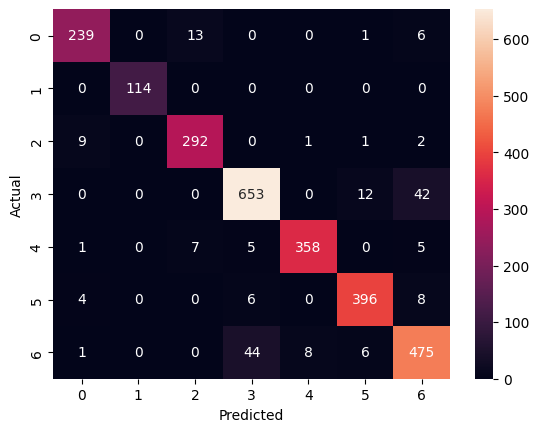

In [66]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# <center>Saving the Model</center>

In [67]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']